In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
import torchvision.models as models

import torch.nn as nn

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

print("All Imports Successful")

All Imports Successful


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/Buliding_damage_project"

CSV_PATH = f"{BASE_DIR}/balanced_dataset.csv"

IMAGE_DIR = f"{BASE_DIR}/images"

MODEL_PATH = f"{BASE_DIR}/dual_efficientnet_final.pth"

print(os.path.exists(CSV_PATH))
print(os.path.exists(IMAGE_DIR))
print(os.path.exists(MODEL_PATH))

True
True
True


In [ ]:
df = pd.read_csv(CSV_PATH)

print(df.shape)

df.head()

(16956, 10)


,uid,label,disaster_type,pre_image,post_image,xmin,ymin,xmax,ymax,area
0,3288f4b7-fe43-4e68-b8c2-61433c62a211,destroyed,fire,santa-rosa-wildfire_00000162_pre_disaster.png,santa-rosa-wildfire_00000162_post_disaster.png,756,244,815,283,2301
1,b67dbfea-09f9-4c40-8276-9fb6281aa9b8,destroyed,tsunami,palu-tsunami_00000112_pre_disaster.png,palu-tsunami_00000112_post_disaster.png,645,960,687,1011,2142
2,48ff0e3b-60df-4395-9118-685b7dac4a1c,destroyed,fire,santa-rosa-wildfire_00000190_pre_disaster.png,santa-rosa-wildfire_00000190_post_disaster.png,813,291,876,315,1512
3,2948acb5-e9ee-40bb-87af-fdea2b3c3694,destroyed,fire,santa-rosa-wildfire_00000063_pre_disaster.png,santa-rosa-wildfire_00000063_post_disaster.png,182,825,227,874,2205
4,a0ee2088-ddac-462d-812b-6b2061a627e2,destroyed,fire,santa-rosa-wildfire_00000079_pre_disaster.png,santa-rosa-wildfire_00000079_post_disaster.png,453,443,534,536,7533


In [ ]:
label_map = {
    "no-damage":0,
    "minor-damage":1,
    "major-damage":2,
    "destroyed":3
}

reverse_label_map = {
    0:"no-damage",
    1:"minor-damage",
    2:"major-damage",
    3:"destroyed"
}

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(val_df.shape)

(3392, 10)


In [ ]:
def crop_building(image, xmin, ymin, xmax, ymax, padding=30):

    xmin = max(0, xmin - padding)
    ymin = max(0, ymin - padding)

    xmax = min(image.shape[1], xmax + padding)
    ymax = min(image.shape[0], ymax + padding)

    crop = image[ymin:ymax, xmin:xmax]

    return crop

In [ ]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
class XBDDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        pre_path = os.path.join(self.image_dir, row["pre_image"])
        post_path = os.path.join(self.image_dir, row["post_image"])

        pre_img = cv2.imread(pre_path)
        post_img = cv2.imread(post_path)

        pre_img = cv2.cvtColor(pre_img, cv2.COLOR_BGR2RGB)
        post_img = cv2.cvtColor(post_img, cv2.COLOR_BGR2RGB)

        pre_crop = crop_building(
            pre_img,
            row["xmin"],
            row["ymin"],
            row["xmax"],
            row["ymax"]
        )

        post_crop = crop_building(
            post_img,
            row["xmin"],
            row["ymin"],
            row["xmax"],
            row["ymax"]
        )

        if self.transform:
            pre_crop = self.transform(pre_crop)
            post_crop = self.transform(post_crop)

        label = label_map[row["label"]]

        return pre_crop, post_crop, label

In [ ]:
print(XBDDataset)

<class '__main__.XBDDataset'>


In [ ]:
val_dataset = XBDDataset(
    val_df,
    IMAGE_DIR,
    transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print(len(val_dataset))

3392


In [ ]:
class DualEfficientNet(nn.Module):

    def __init__(self, num_classes=4):

        super().__init__()

        backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        self.feature_extractor = backbone.features

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(2560, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, pre_img, post_img):

        pre_feat = self.feature_extractor(pre_img)
        pre_feat = self.pool(pre_feat)
        pre_feat = torch.flatten(pre_feat, 1)

        post_feat = self.feature_extractor(post_img)
        post_feat = self.pool(post_feat)
        post_feat = torch.flatten(post_feat, 1)

        fused = torch.cat([pre_feat, post_feat], dim=1)

        return self.classifier(fused)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DualEfficientNet().to(device)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("✅ Model Loaded Successfully")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 93.2MB/s]


✅ Model Loaded Successfully


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

all_preds = []
all_labels = []

with torch.no_grad():

    for pre_imgs, post_imgs, labels in val_loader:

        pre_imgs = pre_imgs.to(device)
        post_imgs = post_imgs.to(device)

        outputs = model(pre_imgs, post_imgs)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Prediction Finished!")

Prediction Finished!


In [20]:
class_names = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed"
]

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   no-damage       0.90      0.71      0.80       848
minor-damage       0.70      0.66      0.68       848
major-damage       0.69      0.81      0.74       848
   destroyed       0.87      0.94      0.90       848

    accuracy                           0.78      3392
   macro avg       0.79      0.78      0.78      3392
weighted avg       0.79      0.78      0.78      3392



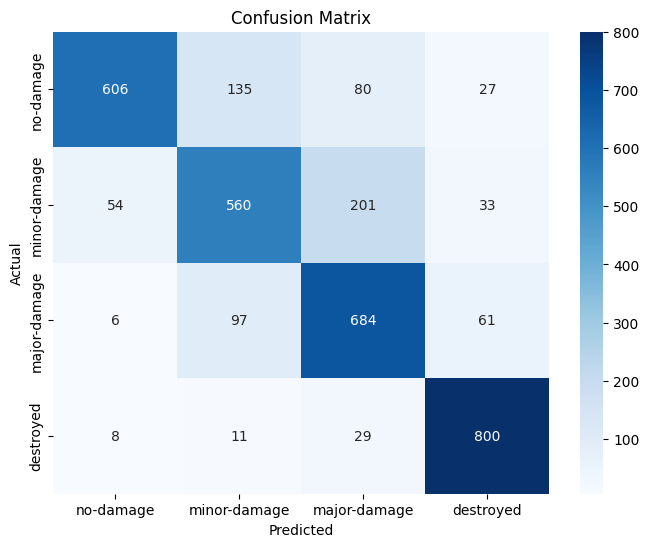

In [21]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()